In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

df=pd.read_csv("student_performance.csv")

In [3]:
df

,study_hours,attendance,internal_score,prev_result,sleep_hours,extra_activity,final_score,pass_fail
0,4.370861,73.983528,42.959305,66.335725,5.570234,2.0,79.347732,1
1,9.556429,76.804818,67.933066,63.542731,5.481873,2.0,94.029095,1
2,7.587945,65.476381,91.106209,31.794945,9.437527,2.0,92.213178,1
3,6.387926,90.689751,81.255742,53.887348,5.497277,2.0,91.375014,1
4,2.404168,84.236559,67.394995,64.844313,7.074599,3.0,83.319560,1
...,...,...,...,...,...,...,...,...
495,5.674864,54.579104,76.774896,75.986861,6.953953,0.0,83.435278,1
496,6.252905,95.865679,67.394995,96.963023,7.463674,0.0,100.000000,1
497,1.699612,56.840932,62.444583,64.844313,7.074599,3.0,60.602613,0
498,9.769553,97.511868,56.585005,33.993830,9.884436,3.0,99.671109,1


In [4]:
feature_cols = ['study_hours', 'attendance', 'internal_score',
                'prev_result', 'sleep_hours', 'extra_activity']

for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers (lower={lower:.2f}, upper={upper:.2f})")

  study_hours: 0 outliers (lower=-2.76, upper=13.89)
  attendance: 0 outliers (lower=30.40, upper=115.75)
  internal_score: 0 outliers (lower=-1.78, upper=132.27)
  prev_result: 0 outliers (lower=2.77, upper=126.60)
  sleep_hours: 0 outliers (lower=2.09, upper=11.97)
  extra_activity: 0 outliers (lower=-4.50, upper=7.50)


In [5]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Before normalization (study_hours):", df['study_hours'].values[:5].round(2))
print("After  normalization (study_hours):", df_scaled['study_hours'].values[:5].round(2))
print("\nNormalized feature means (should be ~0):")
print(df_scaled[feature_cols].mean().round(4))
print("Normalized feature stds (should be ~1):")
print(df_scaled[feature_cols].std().round(4))

Before normalization (study_hours): [4.37 9.56 7.59 6.39 2.4 ]
After  normalization (study_hours): [-0.45  1.56  0.8   0.33 -1.21]

Normalized feature means (should be ~0):
study_hours      -0.0
attendance       -0.0
internal_score   -0.0
prev_result      -0.0
sleep_hours       0.0
extra_activity    0.0
dtype: float64
Normalized feature stds (should be ~1):
study_hours       1.001
attendance        1.001
internal_score    1.001
prev_result       1.001
sleep_hours       1.001
extra_activity    1.001
dtype: float64



 FEATURE SELECTION - PCA ---

Explained variance per component:
  PC1: 0.1907  |  Cumulative: 0.1907
  PC2: 0.1804  |  Cumulative: 0.3712
  PC3: 0.1699  |  Cumulative: 0.5411
  PC4: 0.1633  |  Cumulative: 0.7044
  PC5: 0.1532  |  Cumulative: 0.8575
  PC6: 0.1425  |  Cumulative: 1.0000

Components needed for 95% variance: 6
Shape after PCA: (500, 6)


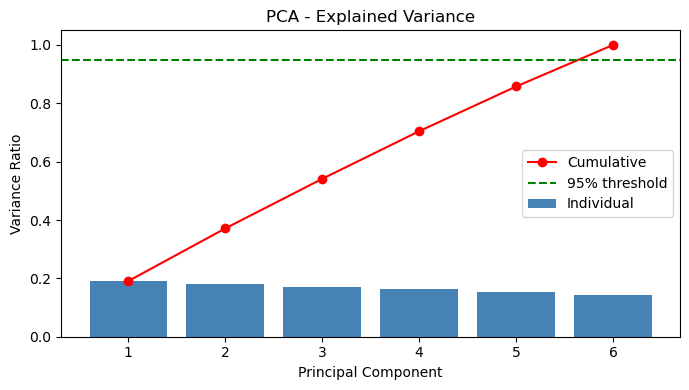

PCA variance plot saved as pca_variance.png


In [6]:
print("\n FEATURE SELECTION - PCA ---")

X_features = df_scaled[feature_cols].values

pca = PCA(n_components=len(feature_cols))
pca.fit(X_features)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("\nExplained variance per component:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {e:.4f}  |  Cumulative: {c:.4f}")

n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

pca_95 = PCA(n_components=n_components_95)
X_pca  = pca_95.fit_transform(X_features)
print(f"Shape after PCA: {X_pca.shape}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained, color='steelblue', label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, 'ro-', label='Cumulative')
ax.axhline(0.95, color='green', linestyle='--', label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Ratio')
ax.set_title('PCA - Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA variance plot saved as pca_variance.png")

In [7]:

print("\nForward Selection Steps:")
for step in range(len(feature_cols)):
    best_score   = 0
    best_feature = None

    for f in remaining_features:
        candidate = selected_features + [f]
        X_cand = X_all[:, candidate]
        X_tr, X_te, y_tr, y_te = train_test_split(X_cand, y_clf,test_size=0.2,random_state=42)
        model = LogisticRegression(max_iter=500)
        model.fit(X_tr, y_tr)
        score = accuracy_score(y_te, model.predict(X_te))
        if score > best_score:
            best_score   = score
            best_feature = f

    if best_feature is not None:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_score_history.append(best_score)
        fname = feature_cols[best_feature]
        print(f"  Step {step+1}: Added '{fname}' | Accuracy = {best_score:.4f}")

fwd_selected_names = [feature_cols[i] for i in selected_features]
print(f"\nForward Selection order: {fwd_selected_names}")


Forward Selection Steps:


NameError: name 'remaining_features' is not defined

In [35]:
print("\n FEATURE SELECTION - BACKWARD ELIMINATION ---")

remaining = list(range(len(feature_cols)))

print("\nBackward Elimination Steps:")
for step in range(len(feature_cols) - 1):
    worst_score   = 2.0
    worst_feature = None

    for f in remaining:
        candidate = [x for x in remaining if x != f]
        X_cand = X_all[:, candidate]
        X_tr, X_te, y_tr, y_te = train_test_split(X_cand, y_clf,
                                                    test_size=0.2,
                                                    random_state=42)
        model = LogisticRegression(max_iter=500)
        model.fit(X_tr, y_tr)
        score = accuracy_score(y_te, model.predict(X_te))
        if score < worst_score:
            worst_score   = score
            worst_feature = f

    if worst_feature is not None:
        fname = feature_cols[worst_feature]
        remaining.remove(worst_feature)
        print(f"  Step {step+1}: Removed '{fname}' | Remaining accuracy = {worst_score:.4f}")

bwd_selected_names = [feature_cols[i] for i in remaining]
print(f"\nBackward Elimination kept: {bwd_selected_names}")


 FEATURE SELECTION - BACKWARD ELIMINATION ---

Backward Elimination Steps:
  Step 1: Removed 'internal_score' | Remaining accuracy = 0.9200
  Step 2: Removed 'sleep_hours' | Remaining accuracy = 0.9200
  Step 3: Removed 'extra_activity' | Remaining accuracy = 0.9200
  Step 4: Removed 'study_hours' | Remaining accuracy = 0.9400
  Step 5: Removed 'attendance' | Remaining accuracy = 0.9400

Backward Elimination kept: ['prev_result']


In [8]:
print("\n---  TRAIN / TEST SPLIT ---")

X = df_scaled[feature_cols].values
y_reg = df_scaled['final_score'].values
y_clf = df_scaled['pass_fail'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Regression  - Train: {X_train_r.shape}, Test: {X_test_r.shape}")
print(f"Classification - Train: {X_train_c.shape}, Test: {X_test_c.shape}")
print("\n FEATURE SELECTION - FORWARD SELECTION ---")
X_all = df_scaled[feature_cols].values
y_clf = df_scaled['pass_fail'].values

remaining_features = list(range(len(feature_cols)))
selected_features  = []
best_score_history = []



---  TRAIN / TEST SPLIT ---
Regression  - Train: (400, 6), Test: (100, 6)
Classification - Train: (400, 6), Test: (100, 6)

 FEATURE SELECTION - FORWARD SELECTION ---


In [9]:
print("\n--- LINEAR REGRESSION ---")

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
lr_pred  = lr_model.predict(X_test_r)

lr_rmse = np.sqrt(mean_squared_error(y_test_r, lr_pred))
lr_r2   = r2_score(y_test_r, lr_pred)

print(f"Linear Regression RMSE : {lr_rmse:.4f}")
print(f"Linear Regression R²   : {lr_r2:.4f}")
print("\nCoefficients:")
for name, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {lr_model.intercept_:.4f}")
print("\n--- RANDOM FOREST REGRESSOR ---")

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
rf_reg_pred = rf_reg.predict(X_test_r)

rf_reg_rmse = np.sqrt(mean_squared_error(y_test_r, rf_reg_pred))
rf_reg_r2   = r2_score(y_test_r, rf_reg_pred)

print(f"Random Forest Regressor RMSE : {rf_reg_rmse:.4f}")
print(f"Random Forest Regressor R²   : {rf_reg_r2:.4f}")

print("\nFeature Importances (Regression):")
for name, imp in zip(feature_cols, rf_reg.feature_importances_):
    bar = '#' * int(imp * 50)
    print(f"  {name:20s}: {imp:.4f}  {bar}")


--- LINEAR REGRESSION ---
Linear Regression RMSE : 4.7203
Linear Regression R²   : 0.8395

Coefficients:
  study_hours: 6.5345
  attendance: 3.2611
  internal_score: 7.0828
  prev_result: 3.0304
  sleep_hours: 1.1098
  extra_activity: -0.0619
Intercept: 84.3398

--- RANDOM FOREST REGRESSOR ---
Random Forest Regressor RMSE : 6.0202
Random Forest Regressor R²   : 0.7389

Feature Importances (Regression):
  study_hours         : 0.3618  ##################
  attendance          : 0.0879  ####
  internal_score      : 0.4157  ####################
  prev_result         : 0.0835  ####
  sleep_hours         : 0.0400  ##
  extra_activity      : 0.0111  



--- PART 17: REGRESSION RESULT PLOTS ---


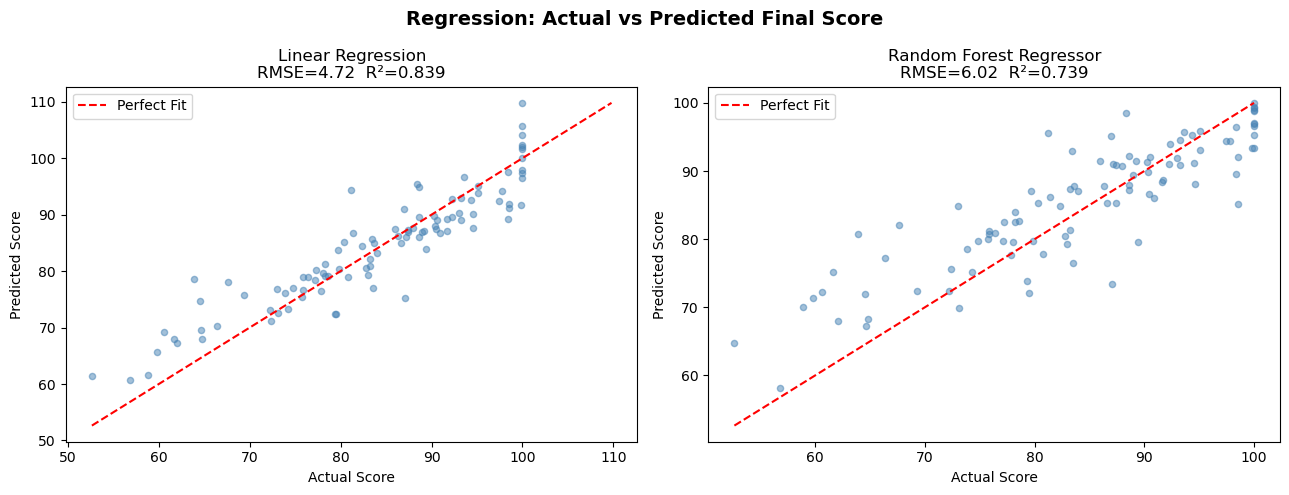

Regression result plot saved as regression_results.png


In [10]:
print("\n--- PART 17: REGRESSION RESULT PLOTS ---")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Regression: Actual vs Predicted Final Score",
             fontsize=14, fontweight='bold')

models_reg = [
    ("Linear Regression",       lr_pred,     lr_rmse,     lr_r2),
    ("Random Forest Regressor", rf_reg_pred, rf_reg_rmse, rf_reg_r2),
]

for ax, (name, pred, rmse, r2) in zip(axes, models_reg):
    ax.scatter(y_test_r, pred, alpha=0.5, color='steelblue', s=20)
    lim = [min(y_test_r.min(), pred.min()), max(y_test_r.max(), pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect Fit')
    ax.set_title(f"{name}\nRMSE={rmse:.2f}  R²={r2:.3f}")
    ax.set_xlabel("Actual Score")
    ax.set_ylabel("Predicted Score")
    ax.legend()

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Regression result plot saved as regression_results.png")

In [11]:
print("\n---  LOGISTIC REGRESSION (Pass/Fail) ---")

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_c, y_train_c)
log_pred = log_model.predict(X_test_c)

log_acc  = accuracy_score(y_test_c, log_pred)
log_prec = precision_score(y_test_c, log_pred, zero_division=0)
log_rec  = recall_score(y_test_c, log_pred, zero_division=0)
log_f1   = f1_score(y_test_c, log_pred, zero_division=0)

print(f"Accuracy  : {log_acc:.4f}")
print(f"Precision : {log_prec:.4f}")
print(f"Recall    : {log_rec:.4f}")
print(f"F1-Score  : {log_f1:.4f}")



---  LOGISTIC REGRESSION (Pass/Fail) ---
Accuracy  : 0.9400
Precision : 0.9684
Recall    : 0.9684
F1-Score  : 0.9684


In [12]:
print("\n-- RANDOM FOREST CLASSIFIER (Pass/Fail) ---")

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
rf_clf_pred = rf_clf.predict(X_test_c)

rf_acc  = accuracy_score(y_test_c, rf_clf_pred)
rf_prec = precision_score(y_test_c, rf_clf_pred, zero_division=0)
rf_rec  = recall_score(y_test_c, rf_clf_pred, zero_division=0)
rf_f1   = f1_score(y_test_c, rf_clf_pred, zero_division=0)

print(f"Accuracy  : {rf_acc:.4f}")
print(f"Precision : {rf_prec:.4f}")
print(f"Recall    : {rf_rec:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

print("\nFeature Importances (Classification):")
for name, imp in zip(feature_cols, rf_clf.feature_importances_):
    bar = '' * int(imp * 50)
    print(f"  {name:20s}: {imp:.4f}  {bar}")
print("\n--- SVM CLASSIFIER (Pass/Fail) ---")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale',
                probability=True, random_state=42)
svm_model.fit(X_train_c, y_train_c)
svm_pred = svm_model.predict(X_test_c)

svm_acc  = accuracy_score(y_test_c, svm_pred)
svm_prec = precision_score(y_test_c, svm_pred, zero_division=0)
svm_rec  = recall_score(y_test_c, svm_pred, zero_division=0)
svm_f1   = f1_score(y_test_c, svm_pred, zero_division=0)

print(f"Accuracy  : {svm_acc:.4f}")
print(f"Precision : {svm_prec:.4f}")
print(f"Recall    : {svm_rec:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")


-- RANDOM FOREST CLASSIFIER (Pass/Fail) ---
Accuracy  : 0.9500
Precision : 0.9500
Recall    : 1.0000
F1-Score  : 0.9744

Feature Importances (Classification):
  study_hours         : 0.2504  
  attendance          : 0.1594  
  internal_score      : 0.3046  
  prev_result         : 0.1592  
  sleep_hours         : 0.0830  
  extra_activity      : 0.0434  

--- SVM CLASSIFIER (Pass/Fail) ---
Accuracy  : 0.9400
Precision : 0.9495
Recall    : 0.9895
F1-Score  : 0.9691


In [13]:
print("\n---MODEL COMPARISON ---")

comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy' : [log_acc, rf_acc, svm_acc],
    'Precision': [log_prec, rf_prec, svm_prec],
    'Recall'   : [log_rec, rf_rec, svm_rec],
    'F1-Score' : [log_f1, rf_f1, svm_f1]
})
comparison = comparison.set_index('Model')
print(comparison.round(4).to_string())

best_model_name = comparison['Accuracy'].idxmax()
best_accuracy   = comparison['Accuracy'].max()
print(f"\nBest model: {best_model_name} with Accuracy = {best_accuracy:.4f}")






---MODEL COMPARISON ---
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression      0.94     0.9684  0.9684    0.9684
Random Forest            0.95     0.9500  1.0000    0.9744
SVM                      0.94     0.9495  0.9895    0.9691

Best model: Random Forest with Accuracy = 0.9500



---: CONFUSION MATRICES ---


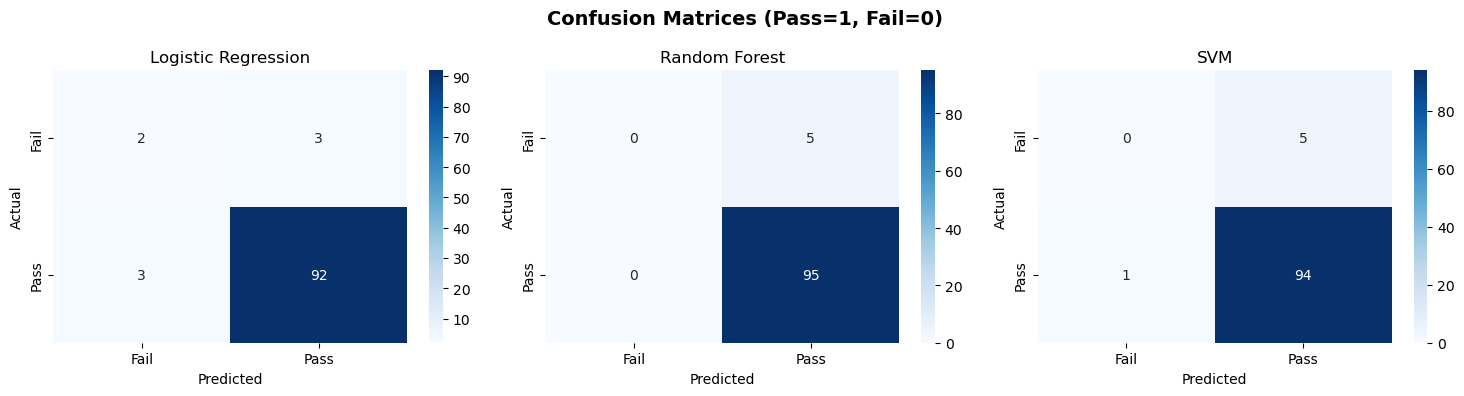

Confusion matrices saved as confusion_matrices.png


In [15]:
print("\n---: CONFUSION MATRICES ---")
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices (Pass=1, Fail=0)",
             fontsize=14, fontweight='bold')

preds  = [log_pred, rf_clf_pred, svm_pred]
names  = ['Logistic Regression', 'Random Forest', 'SVM']

for ax, pred, name in zip(axes, preds, names):
    cm = confusion_matrix(y_test_c, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved as confusion_matrices.png")






--- PART 23: METRICS BAR CHART ---


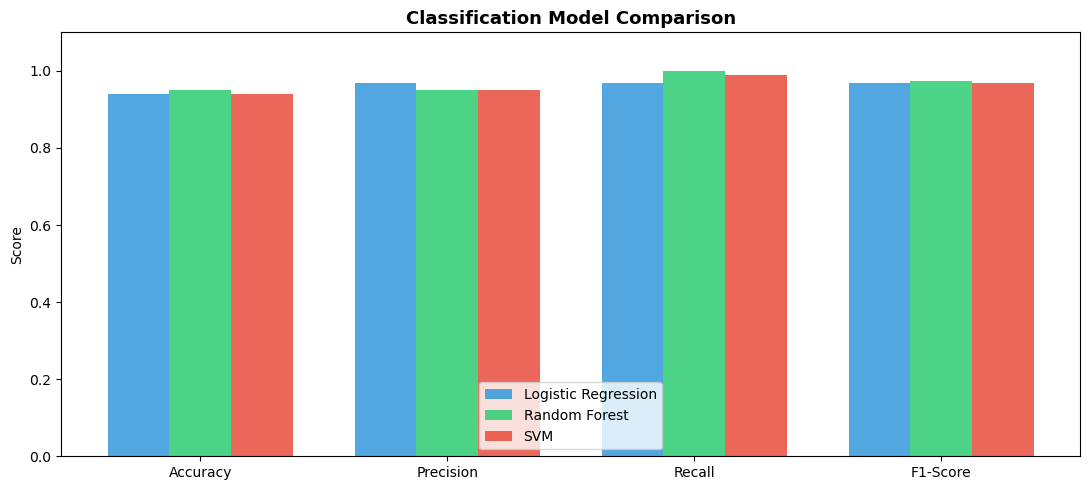

Metrics comparison chart saved as metrics_comparison.png


In [16]:
print("\n--- PART 23: METRICS BAR CHART ---")

metrics_data = {
    'Logistic Regression': [log_acc, log_prec, log_rec, log_f1],
    'Random Forest'       : [rf_acc,  rf_prec,  rf_rec,  rf_f1],
    'SVM'                 : [svm_acc, svm_prec, svm_rec, svm_f1]
}
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x    = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model_name, values) in enumerate(metrics_data.items()):
    ax.bar(x + i * width, values, width,
           label=model_name, color=bar_colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Metrics comparison chart saved as metrics_comparison.png")

In [17]:
print("\n--- AT-RISK STUDENT IDENTIFICATION ---")

best_clf_model = rf_clf
fail_proba     = best_clf_model.predict_proba(X)[:, 0]

df['fail_probability'] = fail_proba
df['risk_label']       = df['fail_probability'].apply(
    lambda p: 'HIGH RISK'   if p >= 0.70 else
              'MEDIUM RISK' if p >= 0.40 else
              'LOW RISK'
)

high_risk   = df[df['risk_label'] == 'HIGH RISK']
medium_risk = df[df['risk_label'] == 'MEDIUM RISK']
low_risk    = df[df['risk_label'] == 'LOW RISK']

print(f"\nTotal students   : {len(df)}")
print(f"HIGH RISK        : {len(high_risk)}")
print(f"MEDIUM RISK      : {len(medium_risk)}")
print(f"LOW RISK         : {len(low_risk)}")

print("\nTop 10 HIGH RISK students:")
print(high_risk[feature_cols + ['final_score', 'fail_probability']
                ].sort_values('fail_probability', ascending=False
                              ).head(10).round(2).to_string())

df.to_csv('student_results.csv', index=False)
print("\nFull student results saved to student_results.csv")




--- AT-RISK STUDENT IDENTIFICATION ---

Total students   : 500
HIGH RISK        : 12
MEDIUM RISK      : 8
LOW RISK         : 480

Top 10 HIGH RISK students:
     study_hours  attendance  internal_score  prev_result  sleep_hours  extra_activity  final_score  fail_probability
202         2.45       66.83           31.55        51.83         6.54             2.0        55.33              0.87
283         1.85       67.28           30.68        74.60         4.27             3.0        56.49              0.84
168         1.37       59.33           30.45        38.15         8.06             1.0        45.21              0.83
72          1.05       69.83           32.95        81.58         5.23             0.0        58.86              0.79
100         1.28       58.45           34.05        43.43         9.49             2.0        55.22              0.77
339         1.88       81.61           32.15        45.72         6.51             1.0        56.81              0.76
128         1.06